# 06 — All-Model Rolling-Origin Comparison and Final Point-Forecast Selection

## Objective

This notebook performs the final homogeneous comparison of the point-forecast
models developed and validated in Notebooks 03, 04 and 05.

The analysis uses only frozen out-of-sample predictions generated over the same
20 expanding-window folds, with a 28-day forecast horizon and 560 target dates
per model.

The main objectives are to:

1. Recover the validated prediction-level artifacts.
2. Apply one homogeneous metric aggregation convention.
3. Compare global accuracy, fold stability, forecast horizons and operational
   conditions.
4. Distinguish universally deployable models from conditionally available
   variants.
5. Select and freeze the final universal point-forecast model.
6. Produce the formal handoff to probabilistic forecasting in Notebook 07.

## Scope restrictions

This is not a model-development notebook.

The following actions are explicitly excluded:

- Re-fitting or retuning previously validated models.
- Changing model specifications after observing outer-backtest results.
- Repeating data-generation or raw-data quality audits.
- Repeating Notebook 04 convergence and residual diagnostics.
- Repeating Notebook 05 leakage, feature-engineering or SHAP audits.
- Creating a model-switching rule without stable out-of-sample evidence.

Only the minimum comparability checks required for a defensible final model
selection are performed.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

PROJECT_ROOT = Path(
    r"C:\Users\Peter\ai-imaging-portfolio"
    r"\projects\06_fintech-liquidity-forecasting"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

# The directories should already exist, but mkdir keeps the notebook portable
# without modifying any validated artifact.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting
Processed data directory: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures


## 1. Recover the validated Notebook 05 handoff

Notebook 05 produced a formal handoff containing the frozen model configuration,
technical summary and artifact registry required for this comparison.

These files are loaded as project metadata. Their previous validations are not
repeated. The only startup check is that the required files remain accessible
and that the frozen all-model prediction artifact is registered.

In [2]:
STARTUP_FILES = {
    "handoff": PROCESSED_DIR / "05_notebook06_handoff.csv",
    "technical_summary": (
        PROCESSED_DIR / "05_notebook05_technical_summary.csv"
    ),
    "artifact_registry": (
        PROCESSED_DIR / "05_notebook05_artifact_registry.csv"
    ),
}

missing_startup_files = [
    path for path in STARTUP_FILES.values() if not path.exists()
]

if missing_startup_files:
    missing_text = "\n".join(str(path) for path in missing_startup_files)
    raise FileNotFoundError(
        "The following required Notebook 05 handoff files were not found:\n"
        f"{missing_text}"
    )

handoff = pd.read_csv(STARTUP_FILES["handoff"])
technical_summary = pd.read_csv(STARTUP_FILES["technical_summary"])
artifact_registry = pd.read_csv(STARTUP_FILES["artifact_registry"])

startup_shapes = pd.DataFrame(
    {
        "table": [
            "handoff",
            "technical_summary",
            "artifact_registry",
        ],
        "rows": [
            len(handoff),
            len(technical_summary),
            len(artifact_registry),
        ],
        "columns": [
            handoff.shape[1],
            technical_summary.shape[1],
            artifact_registry.shape[1],
        ],
    }
)

display(startup_shapes)

print("\nHandoff columns:")
print(handoff.columns.tolist())

print("\nTechnical-summary columns:")
print(technical_summary.columns.tolist())

print("\nArtifact-registry columns:")
print(artifact_registry.columns.tolist())

,table,rows,columns
0,handoff,11,4
1,technical_summary,1,42
2,artifact_registry,82,8



Handoff columns:
['handoff_item', 'value', 'artifact', 'usage_in_notebook06']

Technical-summary columns:
['notebook', 'notebook_status', 'model_name', 'model_family', 'evaluation_role', 'selected_candidate_id', 'selected_target_representation', 'selected_objective', 'multihorizon_strategy', 'feature_count', 'development_internal_folds', 'bounded_candidates_evaluated', 'bounded_candidate_fits', 'outer_folds', 'outer_observations', 'mean_actual', 'mean_prediction', 'mae', 'rmse', 'mean_error', 'bias_percent', 'mase', 'rmsse', 'same_window_descriptive_mae_rank', 'primary_reference_model', 'primary_reference_mae', 'primary_reference_rmse', 'mae_difference_vs_primary', 'mae_difference_vs_primary_percent', 'rmse_difference_vs_primary', 'rmse_difference_vs_primary_percent', 'target_dates_won_by_lightgbm', 'target_dates_won_by_primary', 'folds_won_by_lightgbm_mae', 'top_three_shap_features', 'top_three_shap_share_percent', 'top_five_shap_share_percent', 'top_ten_shap_share_percent', 'outer_r

In [3]:
PREDICTION_FILENAME = "05_same_window_all_model_predictions.csv"

# Search all registry fields because the registry may store the filename,
# relative path or full path in different columns.
registry_as_text = artifact_registry.astype(str)

prediction_registry_mask = registry_as_text.apply(
    lambda column: column.str.contains(
        PREDICTION_FILENAME,
        case=False,
        regex=False,
        na=False,
    )
).any(axis=1)

prediction_registry_entry = artifact_registry.loc[
    prediction_registry_mask
].copy()

if prediction_registry_entry.empty:
    raise ValueError(
        f"{PREDICTION_FILENAME} was not found in the Notebook 05 "
        "artifact registry."
    )

display(prediction_registry_entry)

prediction_path = PROCESSED_DIR / PREDICTION_FILENAME

if not prediction_path.exists():
    raise FileNotFoundError(
        "The prediction artifact is registered but was not found at:\n"
        f"{prediction_path}"
    )

print(f"Frozen prediction artifact ready: {prediction_path}")

,artifact_type,file_name,file_extension,directory,full_path,exists,size_bytes,modified_at
74,processed_artifact,05_same_window_all_model_predictions.csv,.csv,processed,C:\Users\Peter\ai-imaging-portfolio\projects\0...,True,866006,2026-08-05 18:40:32.480649948


Frozen prediction artifact ready: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\05_same_window_all_model_predictions.csv


## 2. Load the frozen all-model prediction dataset

The final comparison begins from the prediction-level artifact produced by
Notebook 05.

The file should contain five validated models evaluated over the same 20
expanding-window folds, with 28 forecast horizons and 560 predictions per
model.

At this stage, no previous model validation is repeated. The dataset is only
inspected to identify its comparison keys, prediction columns and fold-specific
scale denominators before applying the homogeneous metric convention.

In [4]:
all_model_predictions = pd.read_csv(prediction_path)

# Convert only the temporal columns that are present in the saved artifact.
temporal_columns = [
    "train_start",
    "train_end",
    "forecast_origin",
    "test_start",
    "test_end",
    "target_date",
]

for column in temporal_columns:
    if column in all_model_predictions.columns:
        all_model_predictions[column] = pd.to_datetime(
            all_model_predictions[column]
        )

model_inventory = (
    all_model_predictions
    .groupby("model_name", as_index=False)
    .agg(
        prediction_rows=("prediction", "size"),
        folds=("fold_id", "nunique"),
        forecast_horizons=("forecast_horizon", "nunique"),
        target_dates=("target_date", "nunique"),
    )
    .sort_values("model_name")
    .reset_index(drop=True)
)

print(f"Prediction-table shape: {all_model_predictions.shape}")

print("\nPrediction-table columns:")
print(all_model_predictions.columns.tolist())

print("\nModel inventory:")
display(model_inventory)

print("\nFirst prediction rows:")
display(all_model_predictions.head())

Prediction-table shape: (2800, 18)

Prediction-table columns:
['fold_id', 'forecast_origin', 'target_date', 'forecast_horizon', 'model_name', 'model_family', 'evaluation_role', 'actual', 'prediction', 'mase_denominator', 'rmsse_denominator', 'source_notebook', 'result_status', 'error', 'absolute_error', 'squared_error', 'absolute_scaled_error', 'squared_scaled_error']

Model inventory:


,model_name,prediction_rows,folds,forecast_horizons,target_dates
0,calendar_promotion_settlement_trend_arima011_e...,560,20,28,560
1,calendar_promotion_trend_arima011_errors,560,20,28,560
2,ets_log_damped_additive,560,20,28,560
3,historical_weekday_average,560,20,28,560
4,lightgbm_global_direct_relative_rolling56_l2,560,20,28,560



First prediction rows:


,fold_id,forecast_origin,target_date,forecast_horizon,model_name,model_family,evaluation_role,actual,prediction,mase_denominator,rmsse_denominator,source_notebook,result_status,error,absolute_error,squared_error,absolute_scaled_error,squared_scaled_error
0,fold_01,2025-01-17,2025-01-18,1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,692.9770,562.3698,80.7481,110.9341,notebooks_03_and_04,VALIDATED_REFERENCE,-130.6072,130.6072,"17,058.2404",1.6175,1.3861
1,fold_01,2025-01-17,2025-01-19,2,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,468.4260,447.8220,80.7481,110.9341,notebooks_03_and_04,VALIDATED_REFERENCE,-20.6040,20.6040,424.5240,0.2552,0.0345
2,fold_01,2025-01-17,2025-01-20,3,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,774.5850,754.3756,80.7481,110.9341,notebooks_03_and_04,VALIDATED_REFERENCE,-20.2094,20.2094,408.4217,0.2503,0.0332
3,fold_01,2025-01-17,2025-01-21,4,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,758.0830,722.6999,80.7481,110.9341,notebooks_03_and_04,VALIDATED_REFERENCE,-35.3831,35.3831,"1,251.9647",0.4382,0.1017
4,fold_01,2025-01-17,2025-01-22,5,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,721.8540,702.9459,80.7481,110.9341,notebooks_03_and_04,VALIDATED_REFERENCE,-18.9081,18.9081,357.5163,0.2342,0.0291


## 3. Minimum cross-model comparability audit

The five model specifications and their individual backtests were already
validated in previous notebooks.

Notebook 06 therefore performs only the checks required to ensure that the
final ranking compares identical out-of-sample observations:

- one prediction per model and evaluation key;
- the same 560 evaluation keys for every model;
- identical actual values across models;
- identical fold-specific MASE and RMSSE denominators across models.

No model fitting, leakage audit or previous diagnostic is repeated.

In [5]:
# Define the exact unit of comparison used throughout Notebook 06.
COMPARISON_KEYS = [
    "fold_id",
    "forecast_origin",
    "target_date",
    "forecast_horizon",
]

EXPECTED_MODELS = 5
EXPECTED_ROWS_PER_MODEL = 560
EXPECTED_TOTAL_ROWS = EXPECTED_MODELS * EXPECTED_ROWS_PER_MODEL

# Each model must contain exactly one prediction for each evaluation key.
duplicate_prediction_rows = int(
    all_model_predictions.duplicated(
        subset=["model_name", *COMPARISON_KEYS]
    ).sum()
)

# Check whether each evaluation key appears once for every model and whether
# actual values and scale denominators are identical across those models.
key_comparability = (
    all_model_predictions
    .groupby(COMPARISON_KEYS, as_index=False)
    .agg(
        model_count=("model_name", "nunique"),
        actual_count=("actual", "nunique"),
        mase_denominator_count=("mase_denominator", "nunique"),
        rmsse_denominator_count=("rmsse_denominator", "nunique"),
    )
)

comparability_audit = pd.DataFrame(
    [
        {
            "check": "expected_total_prediction_rows",
            "observed": len(all_model_predictions),
            "expected": EXPECTED_TOTAL_ROWS,
            "status": (
                "PASS"
                if len(all_model_predictions) == EXPECTED_TOTAL_ROWS
                else "FAIL"
            ),
        },
        {
            "check": "expected_number_of_models",
            "observed": all_model_predictions["model_name"].nunique(),
            "expected": EXPECTED_MODELS,
            "status": (
                "PASS"
                if all_model_predictions["model_name"].nunique()
                == EXPECTED_MODELS
                else "FAIL"
            ),
        },
        {
            "check": "all_models_have_560_predictions",
            "observed": bool(
                model_inventory["prediction_rows"]
                .eq(EXPECTED_ROWS_PER_MODEL)
                .all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if model_inventory["prediction_rows"]
                .eq(EXPECTED_ROWS_PER_MODEL)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "no_duplicate_model_key_rows",
            "observed": duplicate_prediction_rows,
            "expected": 0,
            "status": (
                "PASS" if duplicate_prediction_rows == 0 else "FAIL"
            ),
        },
        {
            "check": "all_keys_shared_by_five_models",
            "observed": bool(
                key_comparability["model_count"].eq(EXPECTED_MODELS).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if key_comparability["model_count"]
                .eq(EXPECTED_MODELS)
                .all()
                else "FAIL"
            ),
        },
        {
            "check": "actual_values_identical_across_models",
            "observed": bool(
                key_comparability["actual_count"].eq(1).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if key_comparability["actual_count"].eq(1).all()
                else "FAIL"
            ),
        },
        {
            "check": "mase_denominators_identical_across_models",
            "observed": bool(
                key_comparability["mase_denominator_count"].eq(1).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if key_comparability[
                    "mase_denominator_count"
                ].eq(1).all()
                else "FAIL"
            ),
        },
        {
            "check": "rmsse_denominators_identical_across_models",
            "observed": bool(
                key_comparability["rmsse_denominator_count"].eq(1).all()
            ),
            "expected": True,
            "status": (
                "PASS"
                if key_comparability[
                    "rmsse_denominator_count"
                ].eq(1).all()
                else "FAIL"
            ),
        },
    ]
)

comparability_audit_path = (
    PROCESSED_DIR / "06_all_model_comparability_audit.csv"
)

comparability_audit.to_csv(
    comparability_audit_path,
    index=False,
)

assert comparability_audit_path.exists()

display(comparability_audit)

failed_checks = comparability_audit.loc[
    comparability_audit["status"].ne("PASS")
]

if not failed_checks.empty:
    raise ValueError(
        "The frozen model predictions are not fully comparable. "
        "Review the failed checks before calculating final metrics."
    )

print(
    "\nComparability audit passed: "
    f"{len(comparability_audit)} of "
    f"{len(comparability_audit)} checks."
)
print(f"Saved: {comparability_audit_path}")

,check,observed,expected,status
0,expected_total_prediction_rows,2800,2800,PASS
1,expected_number_of_models,5,5,PASS
2,all_models_have_560_predictions,True,True,PASS
3,no_duplicate_model_key_rows,0,0,PASS
4,all_keys_shared_by_five_models,True,True,PASS
5,actual_values_identical_across_models,True,True,PASS
6,mase_denominators_identical_across_models,True,True,PASS
7,rmsse_denominators_identical_across_models,True,True,PASS



Comparability audit passed: 8 of 8 checks.
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_comparability_audit.csv


## 4. Homogeneous aggregate metric convention

All final model metrics are recalculated directly from the 560 frozen
prediction-level rows of each model.

The following pooled conventions are used:

$$
\text{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
| \hat{y}_i-y_i |
$$

$$
\text{RMSE}_{\text{pooled}}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(\hat{y}_i-y_i)^2
}
$$

$$
\text{MASE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{| \hat{y}_i-y_i |}{d^{\text{MASE}}_{f(i)}}
$$

$$
\text{RMSSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\frac{(\hat{y}_i-y_i)^2}
{\left(d^{\text{RMSSE}}_{f(i)}\right)^2}
}
$$

where the scale denominators are calculated from the training history of the
corresponding outer fold.

The pooled RMSE is the official aggregate RMSE used for final model ranking.
The mean of the 20 fold-level RMSE values will be reported separately as a
stability descriptor and will not be mixed with pooled RMSE.

In [6]:
# Recalculate all error quantities from actual and prediction rather than
# depending on metrics previously displayed in different notebooks.
comparison_predictions = all_model_predictions.copy()

comparison_predictions["error"] = (
    comparison_predictions["prediction"]
    - comparison_predictions["actual"]
)

comparison_predictions["absolute_error"] = (
    comparison_predictions["error"].abs()
)

comparison_predictions["squared_error"] = (
    comparison_predictions["error"] ** 2
)

comparison_predictions["absolute_scaled_error"] = (
    comparison_predictions["absolute_error"]
    / comparison_predictions["mase_denominator"]
)

comparison_predictions["squared_scaled_error"] = (
    comparison_predictions["squared_error"]
    / comparison_predictions["rmsse_denominator"].pow(2)
)


def calculate_pooled_metrics(group):
    """Calculate the frozen pooled metric convention for one model."""
    mean_actual = group["actual"].mean()
    mean_error = group["error"].mean()

    return pd.Series(
        {
            "observations": len(group),
            "mean_actual": mean_actual,
            "mean_prediction": group["prediction"].mean(),
            "mean_error": mean_error,
            "bias_percent": 100 * mean_error / mean_actual,
            "mae": group["absolute_error"].mean(),
            "pooled_rmse": np.sqrt(group["squared_error"].mean()),
            "mase": group["absolute_scaled_error"].mean(),
            "rmsse": np.sqrt(
                group["squared_scaled_error"].mean()
            ),
        }
    )


aggregate_metrics = (
    comparison_predictions
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
        ],
        observed=True,
    )
    .apply(
        calculate_pooled_metrics,
        include_groups=False,
    )
    .reset_index()
    .sort_values(
        ["mae", "pooled_rmse"],
        ascending=True,
    )
    .reset_index(drop=True)
)

aggregate_metrics.insert(
    0,
    "accuracy_rank",
    np.arange(1, len(aggregate_metrics) + 1),
)

aggregate_metrics["rmse_aggregation"] = (
    "pooled_over_560_predictions"
)

aggregate_metrics_path = (
    PROCESSED_DIR
    / "06_all_model_homogeneous_aggregate_metrics.csv"
)

aggregate_metrics.to_csv(
    aggregate_metrics_path,
    index=False,
)

assert aggregate_metrics_path.exists()

display(aggregate_metrics)

print(
    "\nOfficial aggregate RMSE convention: "
    "pooled over the 560 prediction-level squared errors."
)
print(f"Saved: {aggregate_metrics_path}")

,accuracy_rank,model_name,model_family,evaluation_role,observations,mean_actual,mean_prediction,mean_error,bias_percent,mae,pooled_rmse,mase,rmsse,rmse_aggregation
0,1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,560.0000,907.6713,912.8764,5.2051,0.5735,60.4518,79.5164,0.6331,0.6020,pooled_over_560_predictions
1,2,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,560.0000,907.6713,912.1305,4.4592,0.4913,63.7503,89.4678,0.6664,0.6707,pooled_over_560_predictions
2,3,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,560.0000,907.6713,912.9594,5.2881,0.5826,74.3162,103.4013,0.7763,0.7747,pooled_over_560_predictions
3,4,ets_log_damped_additive,ets,statistical_benchmark,560.0000,907.6713,899.8455,-7.8258,-0.8622,101.0620,141.3892,1.0530,1.0571,pooled_over_560_predictions
4,5,historical_weekday_average,benchmark,reference_benchmark,560.0000,907.6713,873.1620,-34.5093,-3.8020,106.5762,149.9408,1.1125,1.1205,pooled_over_560_predictions



Official aggregate RMSE convention: pooled over the 560 prediction-level squared errors.
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_homogeneous_aggregate_metrics.csv


## 5. Fold-level metrics and aggregation reconciliation

Each model was evaluated on 20 folds containing 28 predictions each.

Fold-level metrics are calculated for two purposes:

1. Measure temporal stability across evaluation windows.
2. Distinguish pooled squared-error metrics from the arithmetic mean of
   fold-level squared-error metrics.

Because every fold contains the same number of observations, the mean fold MAE
is equal to the pooled MAE. This equivalence does not apply to RMSE or RMSSE
because the square root is calculated before averaging the folds.

The official final-ranking metrics remain:

- pooled RMSE over all 560 predictions;
- pooled RMSSE over all 560 scaled squared errors.

Mean fold RMSE and mean fold RMSSE are retained only as stability descriptors.

In [7]:
def calculate_fold_metrics(group):
    """Calculate point-forecast metrics for one model and outer fold."""
    mean_actual = group["actual"].mean()
    mean_error = group["error"].mean()

    return pd.Series(
        {
            "observations": len(group),
            "mean_actual": mean_actual,
            "mean_prediction": group["prediction"].mean(),
            "mean_error": mean_error,
            "bias_percent": 100 * mean_error / mean_actual,
            "mae": group["absolute_error"].mean(),
            "rmse": np.sqrt(group["squared_error"].mean()),
            "mase": group["absolute_scaled_error"].mean(),
            "rmsse": np.sqrt(
                group["squared_scaled_error"].mean()
            ),
        }
    )


fold_metrics = (
    comparison_predictions
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
            "fold_id",
        ],
        observed=True,
    )
    .apply(
        calculate_fold_metrics,
        include_groups=False,
    )
    .reset_index()
)

fold_metrics_path = (
    PROCESSED_DIR / "06_all_model_fold_metrics.csv"
)

fold_metrics.to_csv(
    fold_metrics_path,
    index=False,
)

assert fold_metrics_path.exists()


fold_stability = (
    fold_metrics
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        folds=("fold_id", "nunique"),
        mean_fold_mae=("mae", "mean"),
        fold_mae_std=("mae", "std"),
        minimum_fold_mae=("mae", "min"),
        maximum_fold_mae=("mae", "max"),
        mean_fold_rmse=("rmse", "mean"),
        fold_rmse_std=("rmse", "std"),
        minimum_fold_rmse=("rmse", "min"),
        maximum_fold_rmse=("rmse", "max"),
        mean_fold_mase=("mase", "mean"),
        mean_fold_rmsse=("rmsse", "mean"),
    )
)

# Add the official pooled metrics to make the aggregation difference explicit.
fold_stability = fold_stability.merge(
    aggregate_metrics[
        [
            "model_name",
            "mae",
            "pooled_rmse",
            "mase",
            "rmsse",
        ]
    ].rename(
        columns={
            "mae": "pooled_mae",
            "mase": "pooled_mase",
            "rmsse": "pooled_rmsse",
        }
    ),
    on="model_name",
    how="left",
    validate="one_to_one",
)

fold_stability["rmse_aggregation_difference"] = (
    fold_stability["pooled_rmse"]
    - fold_stability["mean_fold_rmse"]
)

fold_stability["rmsse_aggregation_difference"] = (
    fold_stability["pooled_rmsse"]
    - fold_stability["mean_fold_rmsse"]
)

fold_stability = (
    fold_stability
    .sort_values("pooled_mae")
    .reset_index(drop=True)
)

fold_stability_path = (
    PROCESSED_DIR / "06_all_model_fold_stability_summary.csv"
)

fold_stability.to_csv(
    fold_stability_path,
    index=False,
)

assert fold_stability_path.exists()

print("Fold-level metrics:")
display(fold_metrics.head())

print("\nFold stability and aggregation reconciliation:")
display(fold_stability)

print(f"\nSaved: {fold_metrics_path}")
print(f"Saved: {fold_stability_path}")

Fold-level metrics:


,model_name,model_family,evaluation_role,fold_id,observations,mean_actual,mean_prediction,mean_error,bias_percent,mae,rmse,mase,rmsse
0,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,fold_01,28.0000,718.0036,713.1357,-4.8679,-0.6780,50.8179,69.2881,0.6293,0.6246
1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,fold_02,28.0000,739.9378,762.9474,23.0097,3.1097,68.4649,82.7527,0.8432,0.7444
2,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,fold_03,28.0000,734.1636,727.3001,-6.8635,-0.9349,53.1406,76.0460,0.6329,0.6581
3,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,fold_04,28.0000,753.4671,762.8030,9.3359,1.2391,42.6898,51.0018,0.5057,0.4409
4,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,fold_05,28.0000,770.0755,786.8731,16.7976,2.1813,66.2341,86.0089,0.7666,0.7273



Fold stability and aggregation reconciliation:


,model_name,model_family,evaluation_role,folds,mean_fold_mae,fold_mae_std,minimum_fold_mae,maximum_fold_mae,mean_fold_rmse,fold_rmse_std,minimum_fold_rmse,maximum_fold_rmse,mean_fold_mase,mean_fold_rmsse,pooled_mae,pooled_rmse,pooled_mase,pooled_rmsse,rmse_aggregation_difference,rmsse_aggregation_difference
0,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,20,60.4518,14.7248,39.1473,85.6565,77.6753,17.4538,51.0018,107.6668,0.6331,0.5895,60.4518,79.5164,0.6331,0.6020,1.8411,0.0126
1,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,20,63.7503,16.4488,38.4542,94.2808,85.8699,25.7694,51.3835,146.3922,0.6664,0.6491,63.7503,89.4678,0.6664,0.6707,3.5980,0.0216
2,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,20,74.3162,19.3702,50.2786,127.6919,99.8033,27.7417,63.0236,164.4113,0.7763,0.7545,74.3162,103.4013,0.7763,0.7747,3.5980,0.0202
3,ets_log_damped_additive,ets,statistical_benchmark,20,101.0620,26.8759,63.7045,161.1571,136.6550,37.2235,85.8869,194.0923,1.0530,1.0310,101.0620,141.3892,1.0530,1.0571,4.7342,0.0262
4,historical_weekday_average,benchmark,reference_benchmark,20,106.5762,24.9102,69.6557,150.0112,145.2047,38.3587,94.9783,210.2648,1.1125,1.0954,106.5762,149.9408,1.1125,1.1205,4.7360,0.0252



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_fold_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_fold_stability_summary.csv


## 6. Fold-level ranking and temporal consistency

Aggregate accuracy can hide periods in which a model performs poorly.

The 20 outer folds are therefore ranked independently using MAE and RMSE.
The resulting win counts measure how consistently each frozen model performs
across time.

The conditional settlement-aware variant remains visible in the descriptive
comparison, but its fold wins do not automatically make it eligible as the
universal operational model.

In [8]:
# Rank models independently within each outer fold.
fold_rankings = fold_metrics.copy()

fold_rankings["mae_rank_within_fold"] = (
    fold_rankings
    .groupby("fold_id")["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

fold_rankings["rmse_rank_within_fold"] = (
    fold_rankings
    .groupby("fold_id")["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

fold_win_summary = (
    fold_rankings
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        folds_evaluated=("fold_id", "nunique"),
        folds_won_mae=(
            "mae_rank_within_fold",
            lambda values: int((values == 1).sum()),
        ),
        folds_won_rmse=(
            "rmse_rank_within_fold",
            lambda values: int((values == 1).sum()),
        ),
        mean_mae_rank=("mae_rank_within_fold", "mean"),
        mean_rmse_rank=("rmse_rank_within_fold", "mean"),
        median_mae_rank=("mae_rank_within_fold", "median"),
        median_rmse_rank=("rmse_rank_within_fold", "median"),
    )
    .merge(
        fold_stability[
            [
                "model_name",
                "mean_fold_mae",
                "fold_mae_std",
                "maximum_fold_mae",
                "mean_fold_rmse",
                "fold_rmse_std",
                "maximum_fold_rmse",
            ]
        ],
        on="model_name",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "mean_mae_rank",
            "mean_rmse_rank",
            "mean_fold_mae",
        ]
    )
    .reset_index(drop=True)
)

fold_rankings_path = (
    PROCESSED_DIR / "06_all_model_fold_rankings.csv"
)

fold_win_summary_path = (
    PROCESSED_DIR / "06_all_model_fold_win_summary.csv"
)

fold_rankings.to_csv(
    fold_rankings_path,
    index=False,
)

fold_win_summary.to_csv(
    fold_win_summary_path,
    index=False,
)

assert fold_rankings_path.exists()
assert fold_win_summary_path.exists()

display(fold_win_summary)

print(f"Saved: {fold_rankings_path}")
print(f"Saved: {fold_win_summary_path}")

,model_name,model_family,evaluation_role,folds_evaluated,folds_won_mae,folds_won_rmse,mean_mae_rank,mean_rmse_rank,median_mae_rank,median_rmse_rank,mean_fold_mae,fold_mae_std,maximum_fold_mae,mean_fold_rmse,fold_rmse_std,maximum_fold_rmse
0,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,20,12,11,1.5500,1.5500,1.0000,1.0000,60.4518,14.7248,85.6565,77.6753,17.4538,107.6668
1,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,20,5,7,1.8000,1.7500,2.0000,2.0000,63.7503,16.4488,94.2808,85.8699,25.7694,146.3922
2,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,20,3,2,2.6500,2.7500,3.0000,3.0000,74.3162,19.3702,127.6919,99.8033,27.7417,164.4113
3,ets_log_damped_additive,ets,statistical_benchmark,20,0,0,4.2000,4.1000,4.0000,4.0000,101.0620,26.8759,161.1571,136.6550,37.2235,194.0923
4,historical_weekday_average,benchmark,reference_benchmark,20,0,0,4.8000,4.8500,5.0000,5.0000,106.5762,24.9102,150.0112,145.2047,38.3587,210.2648


Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_fold_rankings.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_fold_win_summary.csv


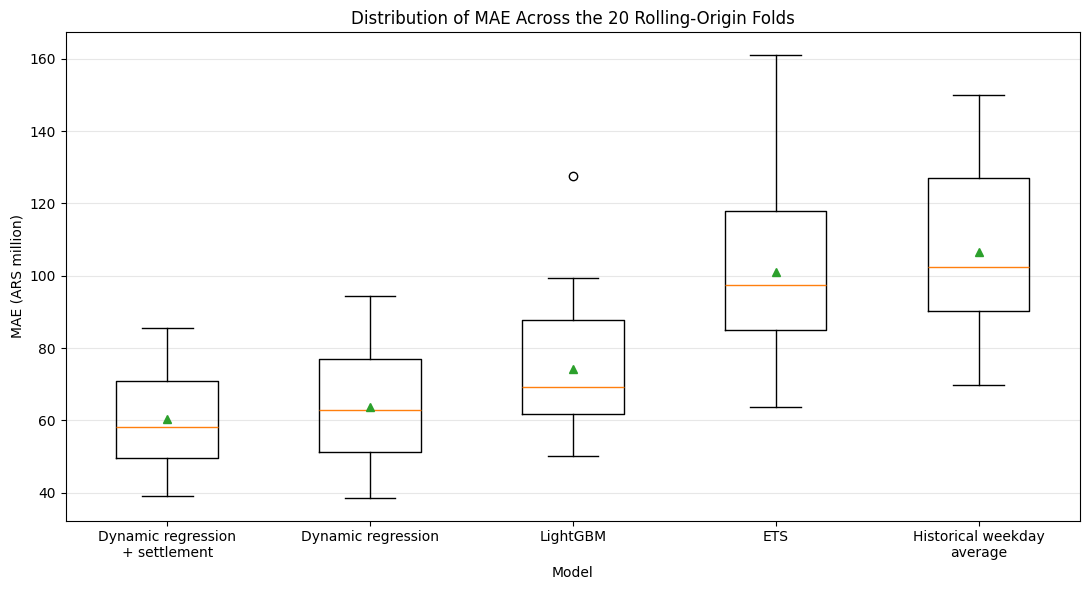

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\06_all_model_fold_mae_distribution.png


In [9]:
# Order models using the official pooled MAE ranking.
model_order = aggregate_metrics["model_name"].tolist()

fold_mae_for_plot = [
    fold_metrics.loc[
        fold_metrics["model_name"].eq(model_name),
        "mae",
    ].to_numpy()
    for model_name in model_order
]

model_labels = [
    {
        "calendar_promotion_settlement_trend_arima011_errors":
            "Dynamic regression\n+ settlement",
        "calendar_promotion_trend_arima011_errors":
            "Dynamic regression",
        "lightgbm_global_direct_relative_rolling56_l2":
            "LightGBM",
        "ets_log_damped_additive":
            "ETS",
        "historical_weekday_average":
            "Historical weekday\naverage",
    }.get(model_name, model_name)
    for model_name in model_order
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.boxplot(
    fold_mae_for_plot,
    tick_labels=model_labels,
    showmeans=True,
)

ax.set_title(
    "Distribution of MAE Across the 20 Rolling-Origin Folds"
)
ax.set_xlabel("Model")
ax.set_ylabel("MAE (ARS million)")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fold_mae_figure_path = (
    FIGURES_DIR / "06_all_model_fold_mae_distribution.png"
)

fig.savefig(
    fold_mae_figure_path,
    dpi=300,
    bbox_inches="tight",
)

assert fold_mae_figure_path.exists()

plt.show()

print(f"Saved: {fold_mae_figure_path}")

## 7. Forecast-horizon comparison

Forecast accuracy is evaluated separately for each horizon from 1 to 28 days.

This analysis identifies whether a model performs consistently across the full
planning horizon or whether its aggregate result depends on a small number of
specific lead times.

The comparison remains descriptive for the settlement-aware model because its
future regressor availability is conditional.

No horizon-specific switching rule will be created unless a stable and
operationally defensible pattern is observed.

In [10]:
def calculate_horizon_metrics(group):
    """Calculate pooled metrics for one model and forecast horizon."""
    mean_actual = group["actual"].mean()
    mean_error = group["error"].mean()

    return pd.Series(
        {
            "observations": len(group),
            "mean_actual": mean_actual,
            "mean_prediction": group["prediction"].mean(),
            "mean_error": mean_error,
            "bias_percent": 100 * mean_error / mean_actual,
            "mae": group["absolute_error"].mean(),
            "rmse": np.sqrt(group["squared_error"].mean()),
            "mase": group["absolute_scaled_error"].mean(),
            "rmsse": np.sqrt(
                group["squared_scaled_error"].mean()
            ),
        }
    )


horizon_metrics = (
    comparison_predictions
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
            "forecast_horizon",
        ],
        observed=True,
    )
    .apply(
        calculate_horizon_metrics,
        include_groups=False,
    )
    .reset_index()
)

horizon_metrics["mae_rank_within_horizon"] = (
    horizon_metrics
    .groupby("forecast_horizon")["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

horizon_metrics["rmse_rank_within_horizon"] = (
    horizon_metrics
    .groupby("forecast_horizon")["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

horizon_win_summary = (
    horizon_metrics
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        horizons_evaluated=("forecast_horizon", "nunique"),
        horizons_won_mae=(
            "mae_rank_within_horizon",
            lambda values: int((values == 1).sum()),
        ),
        horizons_won_rmse=(
            "rmse_rank_within_horizon",
            lambda values: int((values == 1).sum()),
        ),
        mean_horizon_mae_rank=(
            "mae_rank_within_horizon",
            "mean",
        ),
        mean_horizon_rmse_rank=(
            "rmse_rank_within_horizon",
            "mean",
        ),
        median_horizon_mae_rank=(
            "mae_rank_within_horizon",
            "median",
        ),
        median_horizon_rmse_rank=(
            "rmse_rank_within_horizon",
            "median",
        ),
        mean_horizon_mae=("mae", "mean"),
        maximum_horizon_mae=("mae", "max"),
        mean_horizon_rmse=("rmse", "mean"),
        maximum_horizon_rmse=("rmse", "max"),
    )
    .sort_values(
        [
            "mean_horizon_mae_rank",
            "mean_horizon_rmse_rank",
        ]
    )
    .reset_index(drop=True)
)

horizon_metrics_path = (
    PROCESSED_DIR / "06_all_model_horizon_metrics.csv"
)

horizon_win_summary_path = (
    PROCESSED_DIR / "06_all_model_horizon_win_summary.csv"
)

horizon_metrics.to_csv(
    horizon_metrics_path,
    index=False,
)

horizon_win_summary.to_csv(
    horizon_win_summary_path,
    index=False,
)

assert horizon_metrics_path.exists()
assert horizon_win_summary_path.exists()

display(horizon_win_summary)

print("\nMAE winner by forecast horizon:")

display(
    horizon_metrics.loc[
        horizon_metrics["mae_rank_within_horizon"].eq(1),
        [
            "forecast_horizon",
            "model_name",
            "mae",
            "rmse",
        ],
    ].sort_values("forecast_horizon")
)

print(f"\nSaved: {horizon_metrics_path}")
print(f"Saved: {horizon_win_summary_path}")

,model_name,model_family,evaluation_role,horizons_evaluated,horizons_won_mae,horizons_won_rmse,mean_horizon_mae_rank,mean_horizon_rmse_rank,median_horizon_mae_rank,median_horizon_rmse_rank,mean_horizon_mae,maximum_horizon_mae,mean_horizon_rmse,maximum_horizon_rmse
0,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,28,15,14,1.4643,1.5000,1.0000,1.5000,60.4518,84.2855,76.6376,125.7508
1,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,28,10,11,1.8214,1.7500,2.0000,2.0000,63.7503,101.9734,84.0969,162.4744
2,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,28,2,3,2.9286,2.7857,3.0000,3.0000,74.3162,112.0480,97.8683,166.6239
3,ets_log_damped_additive,ets,statistical_benchmark,28,1,0,4.0714,4.2143,4.0000,4.0000,101.0620,152.4450,133.1220,214.7948
4,historical_weekday_average,benchmark,reference_benchmark,28,0,0,4.7143,4.7500,5.0000,5.0000,106.5762,151.1732,142.2130,209.5926



MAE winner by forecast horizon:


,forecast_horizon,model_name,mae,rmse
112,1,lightgbm_global_direct_relative_rolling56_l2,41.5148,53.6984
29,2,calendar_promotion_trend_arima011_errors,28.1370,34.8991
2,3,calendar_promotion_settlement_trend_arima011_e...,61.9669,76.9343
31,4,calendar_promotion_trend_arima011_errors,71.8473,87.7161
4,5,calendar_promotion_settlement_trend_arima011_e...,59.7895,75.5617
33,6,calendar_promotion_trend_arima011_errors,64.9967,85.9248
6,7,calendar_promotion_settlement_trend_arima011_e...,69.7449,83.5824
35,8,calendar_promotion_trend_arima011_errors,41.6854,52.5289
8,9,calendar_promotion_settlement_trend_arima011_e...,33.4018,45.9321
9,10,calendar_promotion_settlement_trend_arima011_e...,63.6311,74.4952



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_horizon_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_horizon_win_summary.csv


### Horizon-band consistency

Individual horizon wins may be caused by local variation across only 20
observations per horizon.

To evaluate whether the performance differences persist over meaningful
planning periods, the 28-day forecast horizon is divided into four weekly
bands:

- Days 1–7.
- Days 8–14.
- Days 15–21.
- Days 22–28.

These bands are descriptive summaries. They are not used to create a
horizon-specific switching policy.

In [11]:
HORIZON_BANDS = [
    "days_01_07",
    "days_08_14",
    "days_15_21",
    "days_22_28",
]

comparison_predictions["horizon_band"] = pd.cut(
    comparison_predictions["forecast_horizon"],
    bins=[0, 7, 14, 21, 28],
    labels=HORIZON_BANDS,
    include_lowest=True,
)


def calculate_horizon_band_metrics(group):
    """Calculate pooled metrics for one model and seven-day horizon band."""
    mean_actual = group["actual"].mean()
    mean_error = group["error"].mean()

    return pd.Series(
        {
            "observations": len(group),
            "mean_actual": mean_actual,
            "mean_prediction": group["prediction"].mean(),
            "mean_error": mean_error,
            "bias_percent": 100 * mean_error / mean_actual,
            "mae": group["absolute_error"].mean(),
            "rmse": np.sqrt(group["squared_error"].mean()),
            "mase": group["absolute_scaled_error"].mean(),
            "rmsse": np.sqrt(
                group["squared_scaled_error"].mean()
            ),
        }
    )


horizon_band_metrics = (
    comparison_predictions
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
            "horizon_band",
        ],
        observed=True,
    )
    .apply(
        calculate_horizon_band_metrics,
        include_groups=False,
    )
    .reset_index()
)

horizon_band_metrics["mae_rank_within_band"] = (
    horizon_band_metrics
    .groupby("horizon_band", observed=True)["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

horizon_band_metrics["rmse_rank_within_band"] = (
    horizon_band_metrics
    .groupby("horizon_band", observed=True)["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

horizon_band_win_summary = (
    horizon_band_metrics
    .groupby(
        [
            "model_name",
            "model_family",
            "evaluation_role",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        bands_evaluated=("horizon_band", "nunique"),
        bands_won_mae=(
            "mae_rank_within_band",
            lambda values: int((values == 1).sum()),
        ),
        bands_won_rmse=(
            "rmse_rank_within_band",
            lambda values: int((values == 1).sum()),
        ),
        mean_band_mae_rank=("mae_rank_within_band", "mean"),
        mean_band_rmse_rank=("rmse_rank_within_band", "mean"),
    )
    .sort_values(
        [
            "mean_band_mae_rank",
            "mean_band_rmse_rank",
        ]
    )
    .reset_index(drop=True)
)

horizon_band_metrics_path = (
    PROCESSED_DIR / "06_all_model_horizon_band_metrics.csv"
)

horizon_band_win_summary_path = (
    PROCESSED_DIR / "06_all_model_horizon_band_win_summary.csv"
)

horizon_band_metrics.to_csv(
    horizon_band_metrics_path,
    index=False,
)

horizon_band_win_summary.to_csv(
    horizon_band_win_summary_path,
    index=False,
)

assert horizon_band_metrics_path.exists()
assert horizon_band_win_summary_path.exists()

print("Horizon-band win summary:")
display(horizon_band_win_summary)

print("\nMAE winner by horizon band:")
display(
    horizon_band_metrics.loc[
        horizon_band_metrics["mae_rank_within_band"].eq(1),
        [
            "horizon_band",
            "model_name",
            "observations",
            "mae",
            "rmse",
            "bias_percent",
        ],
    ].sort_values("horizon_band")
)

print(f"\nSaved: {horizon_band_metrics_path}")
print(f"Saved: {horizon_band_win_summary_path}")

Horizon-band win summary:


,model_name,model_family,evaluation_role,bands_evaluated,bands_won_mae,bands_won_rmse,mean_band_mae_rank,mean_band_rmse_rank
0,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,4,4,4,1.0000,1.0000
1,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,4,0,0,2.0000,2.0000
2,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,4,0,0,3.0000,3.0000
3,ets_log_damped_additive,ets,statistical_benchmark,4,0,0,4.0000,4.0000
4,historical_weekday_average,benchmark,reference_benchmark,4,0,0,5.0000,5.0000



MAE winner by horizon band:


,horizon_band,model_name,observations,mae,rmse,bias_percent
0,days_01_07,calendar_promotion_settlement_trend_arima011_e...,140.0000,57.2909,73.7609,-0.1180
1,days_08_14,calendar_promotion_settlement_trend_arima011_e...,140.0000,60.4103,84.2597,0.1250
2,days_15_21,calendar_promotion_settlement_trend_arima011_e...,140.0000,58.3580,73.6381,2.0183
3,days_22_28,calendar_promotion_settlement_trend_arima011_e...,140.0000,65.7480,85.6066,0.2857



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_horizon_band_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_horizon_band_win_summary.csv


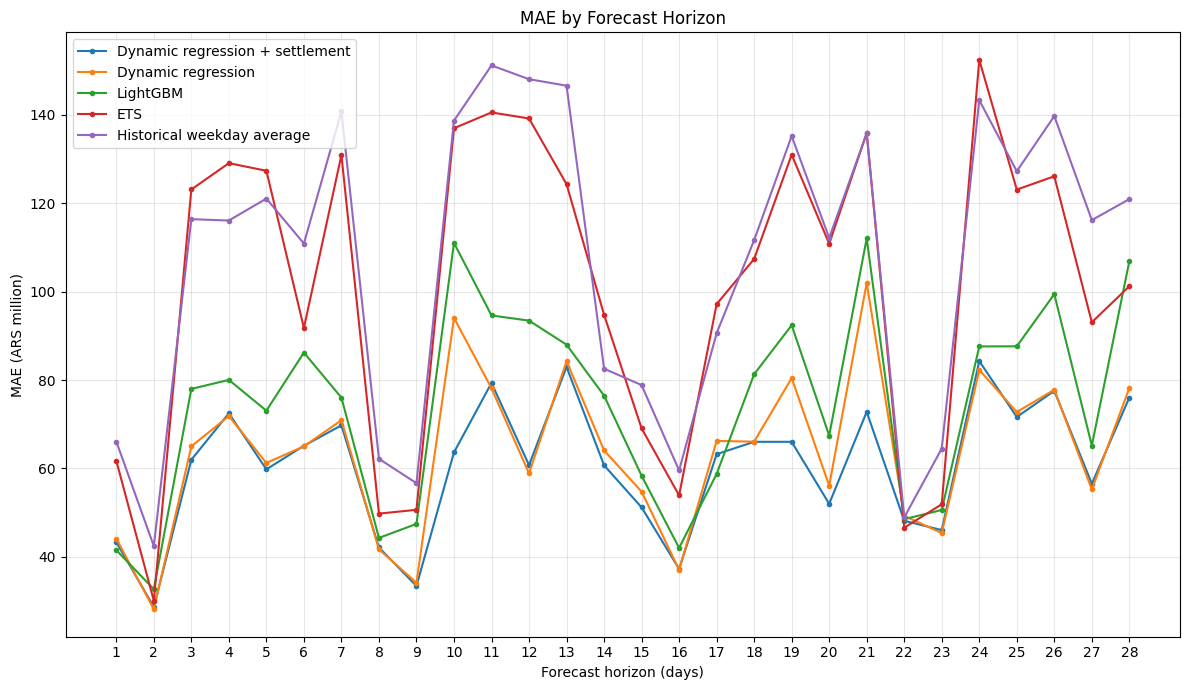

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\06_all_model_mae_by_forecast_horizon.png


In [12]:
DISPLAY_NAMES = {
    "calendar_promotion_settlement_trend_arima011_errors":
        "Dynamic regression + settlement",
    "calendar_promotion_trend_arima011_errors":
        "Dynamic regression",
    "lightgbm_global_direct_relative_rolling56_l2":
        "LightGBM",
    "ets_log_damped_additive":
        "ETS",
    "historical_weekday_average":
        "Historical weekday average",
}

fig, ax = plt.subplots(figsize=(12, 7))

for model_name in model_order:
    model_horizon_metrics = (
        horizon_metrics.loc[
            horizon_metrics["model_name"].eq(model_name)
        ]
        .sort_values("forecast_horizon")
    )

    ax.plot(
        model_horizon_metrics["forecast_horizon"],
        model_horizon_metrics["mae"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=DISPLAY_NAMES.get(model_name, model_name),
    )

ax.set_title("MAE by Forecast Horizon")
ax.set_xlabel("Forecast horizon (days)")
ax.set_ylabel("MAE (ARS million)")
ax.set_xticks(range(1, 29))
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()

horizon_mae_figure_path = (
    FIGURES_DIR / "06_all_model_mae_by_forecast_horizon.png"
)

fig.savefig(
    horizon_mae_figure_path,
    dpi=300,
    bbox_inches="tight",
)

assert horizon_mae_figure_path.exists()

plt.show()

print(f"Saved: {horizon_mae_figure_path}")

## 8. Recover operational conditions

The frozen prediction artifact contains the model outputs and evaluation keys,
but it does not duplicate the calendar and event variables from the validated
daily dataset.

The relevant target-date conditions are therefore recovered once and merged
into the canonical comparison table.

The analysis uses:

- weekend status;
- holidays;
- payday windows;
- month-end dates;
- active promotions;
- scheduled merchant settlements.

This merge does not revalidate the original dataset. It only attaches previously
validated target-date information to the 2,800 frozen predictions.

In [13]:
RAW_DIR = PROJECT_ROOT / "data" / "raw"

REQUIRED_CONDITION_COLUMNS = [
    "date",
    "is_weekend",
    "is_holiday",
    "is_payday_window",
    "is_month_end",
    "promotion_intensity",
    "merchant_settlement_intensity",
]

# Locate the validated daily dataset from its required schema rather than
# hard-coding a filename that may differ between project versions.
candidate_files = sorted(
    list(RAW_DIR.glob("*.csv"))
    + list(PROCESSED_DIR.glob("*.csv"))
)

candidate_records = []

for candidate_path in candidate_files:
    try:
        candidate_columns = pd.read_csv(
            candidate_path,
            nrows=0,
        ).columns.tolist()
    except Exception:
        continue

    if set(REQUIRED_CONDITION_COLUMNS).issubset(candidate_columns):
        candidate_dates = pd.read_csv(
            candidate_path,
            usecols=["date"],
            parse_dates=["date"],
        )

        candidate_records.append(
            {
                "file_name": candidate_path.name,
                "full_path": str(candidate_path),
                "directory": candidate_path.parent.name,
                "rows": len(candidate_dates),
                "start_date": candidate_dates["date"].min(),
                "end_date": candidate_dates["date"].max(),
            }
        )

condition_source_candidates = pd.DataFrame(candidate_records)

if condition_source_candidates.empty:
    raise FileNotFoundError(
        "No CSV file containing all required operational-condition "
        "columns was found."
    )

evaluation_start = comparison_predictions["target_date"].min()
evaluation_end = comparison_predictions["target_date"].max()

eligible_condition_sources = condition_source_candidates.loc[
    condition_source_candidates["start_date"].le(evaluation_start)
    & condition_source_candidates["end_date"].ge(evaluation_end)
    & condition_source_candidates["rows"].eq(1308)
].copy()

# Prefer the original validated raw dataset when exactly one such file exists.
raw_eligible_sources = eligible_condition_sources.loc[
    eligible_condition_sources["directory"].eq("raw")
]

if len(raw_eligible_sources) == 1:
    selected_condition_source = Path(
        raw_eligible_sources.iloc[0]["full_path"]
    )
elif len(eligible_condition_sources) == 1:
    selected_condition_source = Path(
        eligible_condition_sources.iloc[0]["full_path"]
    )
else:
    display(condition_source_candidates)

    raise ValueError(
        "The validated daily condition source could not be selected "
        "unambiguously. Review the candidate table displayed above."
    )

daily_conditions = pd.read_csv(
    selected_condition_source,
    usecols=REQUIRED_CONDITION_COLUMNS,
    parse_dates=["date"],
)

daily_conditions = daily_conditions.rename(
    columns={"date": "target_date"}
)

comparison_predictions = comparison_predictions.merge(
    daily_conditions,
    on="target_date",
    how="left",
    validate="many_to_one",
)

# Convert event intensities into operational condition indicators.
comparison_predictions["promotion_active"] = (
    comparison_predictions["promotion_intensity"].gt(0)
)

comparison_predictions["settlement_active"] = (
    comparison_predictions[
        "merchant_settlement_intensity"
    ].gt(0)
)

condition_columns = [
    "is_weekend",
    "is_holiday",
    "is_payday_window",
    "is_month_end",
    "promotion_active",
    "settlement_active",
]

assert len(comparison_predictions) == EXPECTED_TOTAL_ROWS
assert comparison_predictions[condition_columns].notna().all().all()

predictions_with_conditions_path = (
    PROCESSED_DIR
    / "06_all_model_predictions_with_conditions.csv"
)

comparison_predictions.to_csv(
    predictions_with_conditions_path,
    index=False,
)

assert predictions_with_conditions_path.exists()

condition_support = (
    comparison_predictions[
        ["target_date", *condition_columns]
    ]
    .drop_duplicates("target_date")
    [condition_columns]
    .sum()
    .rename("target_dates")
    .reset_index()
    .rename(columns={"index": "condition"})
)

print(f"Condition source: {selected_condition_source}")

print("\nOut-of-sample condition support:")
display(condition_support)

print(f"\nSaved: {predictions_with_conditions_path}")

Condition source: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\raw\synthetic_fintech_daily.csv

Out-of-sample condition support:


,condition,target_dates
0,is_weekend,160
1,is_holiday,32
2,is_payday_window,108
3,is_month_end,19
4,promotion_active,16
5,settlement_active,3



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_predictions_with_conditions.csv


## 9. Performance by operational condition

Model performance is compared on target dates associated with relevant
calendar and operational conditions.

The comparison includes all five models for descriptive completeness.
A second ranking excludes the settlement-aware specification because that
model requires a complete and reliable future settlement schedule.

Condition-level results must be interpreted together with their out-of-sample
support. In particular, the settlement condition contains only three target
dates and cannot provide general validation of the conditional model.

In [14]:
CONDITION_LABELS = {
    "is_weekend": "Weekend",
    "is_holiday": "Holiday",
    "is_payday_window": "Payday window",
    "is_month_end": "Month end",
    "promotion_active": "Promotion active",
    "settlement_active": "Settlement active",
}

CONDITIONAL_MODEL = (
    "calendar_promotion_settlement_trend_arima011_errors"
)

# Convert the condition columns to long format and retain only active dates.
condition_predictions = comparison_predictions.melt(
    id_vars=[
        "fold_id",
        "forecast_origin",
        "target_date",
        "forecast_horizon",
        "model_name",
        "model_family",
        "evaluation_role",
        "actual",
        "prediction",
        "error",
        "absolute_error",
        "squared_error",
        "absolute_scaled_error",
        "squared_scaled_error",
    ],
    value_vars=condition_columns,
    var_name="condition",
    value_name="condition_active",
)

condition_predictions = condition_predictions.loc[
    condition_predictions["condition_active"].astype(bool)
].copy()

condition_predictions["condition_label"] = (
    condition_predictions["condition"].map(CONDITION_LABELS)
)


def calculate_condition_metrics(group):
    """Calculate pooled metrics for one model and active condition."""
    mean_actual = group["actual"].mean()
    mean_error = group["error"].mean()

    return pd.Series(
        {
            "target_dates": group["target_date"].nunique(),
            "observations": len(group),
            "mean_actual": mean_actual,
            "mean_prediction": group["prediction"].mean(),
            "mean_error": mean_error,
            "bias_percent": 100 * mean_error / mean_actual,
            "mae": group["absolute_error"].mean(),
            "rmse": np.sqrt(group["squared_error"].mean()),
            "mase": group["absolute_scaled_error"].mean(),
            "rmsse": np.sqrt(
                group["squared_scaled_error"].mean()
            ),
        }
    )


condition_metrics = (
    condition_predictions
    .groupby(
        [
            "condition",
            "condition_label",
            "model_name",
            "model_family",
            "evaluation_role",
        ],
        observed=True,
    )
    .apply(
        calculate_condition_metrics,
        include_groups=False,
    )
    .reset_index()
)

# Descriptive ranking across all five frozen models.
condition_metrics["mae_rank_all_models"] = (
    condition_metrics
    .groupby("condition")["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

condition_metrics["rmse_rank_all_models"] = (
    condition_metrics
    .groupby("condition")["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

condition_metrics["operational_scope"] = np.where(
    condition_metrics["model_name"].eq(CONDITIONAL_MODEL),
    "conditional",
    "universal",
)

condition_metrics_path = (
    PROCESSED_DIR
    / "06_all_model_operational_condition_metrics.csv"
)

condition_metrics.to_csv(
    condition_metrics_path,
    index=False,
)

assert condition_metrics_path.exists()


# Best descriptive model among all five candidates.
all_model_condition_winners = (
    condition_metrics.loc[
        condition_metrics["mae_rank_all_models"].eq(1),
        [
            "condition",
            "condition_label",
            "model_name",
            "operational_scope",
            "target_dates",
            "mae",
            "rmse",
            "bias_percent",
        ],
    ]
    .sort_values("condition")
    .reset_index(drop=True)
)

all_model_condition_winners_path = (
    PROCESSED_DIR
    / "06_all_model_operational_condition_winners.csv"
)

all_model_condition_winners.to_csv(
    all_model_condition_winners_path,
    index=False,
)

assert all_model_condition_winners_path.exists()


# Repeat the ranking using only universally deployable models.
universal_condition_metrics = condition_metrics.loc[
    condition_metrics["operational_scope"].eq("universal")
].copy()

universal_condition_metrics["mae_rank_universal"] = (
    universal_condition_metrics
    .groupby("condition")["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_condition_metrics["rmse_rank_universal"] = (
    universal_condition_metrics
    .groupby("condition")["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_condition_winners = (
    universal_condition_metrics.loc[
        universal_condition_metrics["mae_rank_universal"].eq(1),
        [
            "condition",
            "condition_label",
            "model_name",
            "target_dates",
            "mae",
            "rmse",
            "bias_percent",
        ],
    ]
    .sort_values("condition")
    .reset_index(drop=True)
)

universal_condition_winners_path = (
    PROCESSED_DIR
    / "06_universal_model_operational_condition_winners.csv"
)

universal_condition_winners.to_csv(
    universal_condition_winners_path,
    index=False,
)

assert universal_condition_winners_path.exists()


print("Best descriptive model by active condition:")
display(all_model_condition_winners)

print("\nBest universally deployable model by active condition:")
display(universal_condition_winners)

print(f"\nSaved: {condition_metrics_path}")
print(f"Saved: {all_model_condition_winners_path}")
print(f"Saved: {universal_condition_winners_path}")

Best descriptive model by active condition:


,condition,condition_label,model_name,operational_scope,target_dates,mae,rmse,bias_percent
0,is_holiday,Holiday,calendar_promotion_settlement_trend_arima011_e...,conditional,32.0000,54.1738,66.4953,-0.8776
1,is_month_end,Month end,calendar_promotion_settlement_trend_arima011_e...,conditional,19.0000,73.2883,95.0595,-0.1516
2,is_payday_window,Payday window,calendar_promotion_settlement_trend_arima011_e...,conditional,108.0000,86.7481,109.5886,0.8636
3,is_weekend,Weekend,calendar_promotion_settlement_trend_arima011_e...,conditional,160.0000,41.2642,51.3015,-0.2074
4,promotion_active,Promotion active,calendar_promotion_trend_arima011_errors,universal,16.0000,54.6988,67.0167,0.1569
5,settlement_active,Settlement active,calendar_promotion_settlement_trend_arima011_e...,conditional,3.0000,69.6559,72.0805,4.4697



Best universally deployable model by active condition:


,condition,condition_label,model_name,target_dates,mae,rmse,bias_percent
0,is_holiday,Holiday,calendar_promotion_trend_arima011_errors,32.0000,55.8791,68.0236,-0.8467
1,is_month_end,Month end,calendar_promotion_trend_arima011_errors,19.0000,89.9615,124.2302,-0.1297
2,is_payday_window,Payday window,calendar_promotion_trend_arima011_errors,108.0000,87.0633,109.5812,0.9815
3,is_weekend,Weekend,calendar_promotion_trend_arima011_errors,160.0000,41.8181,52.0494,-0.0662
4,promotion_active,Promotion active,calendar_promotion_trend_arima011_errors,16.0000,54.6988,67.0167,0.1569
5,settlement_active,Settlement active,lightgbm_global_direct_relative_rolling56_l2,3.0000,463.4387,478.7017,-29.7380



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_operational_condition_metrics.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_all_model_operational_condition_winners.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_universal_model_operational_condition_winners.csv


## 10. Operational eligibility and evidence support

Raw predictive accuracy is not sufficient to define the final universal model.

The settlement-aware dynamic regression requires a complete and reliable future
merchant-settlement schedule. Although it achieves the lowest aggregate errors,
only three settlement target dates are available in the outer backtest.

It is therefore retained as a conditional operational variant and excluded from
the universal-model ranking.

The settlement condition is also excluded from the general condition-win count.
Its three observations remain reported transparently, but they do not provide
sufficient evidence for a universal model-selection decision.

The final universal comparison follows a hierarchical rubric:

1. Operational eligibility.
2. Homogeneous out-of-sample accuracy.
3. Stability across folds.
4. Consistency across weekly horizon bands.
5. Performance across supported operational conditions.
6. Interpretability and implementation complexity.

No arbitrary weighted composite score is used.

In [15]:
condition_evidence = condition_support.copy()

condition_evidence["condition_label"] = (
    condition_evidence["condition"].map(CONDITION_LABELS)
)

condition_evidence["evidence_status"] = np.where(
    condition_evidence["condition"].eq("settlement_active"),
    "LIMITED_SUPPORT_3_TARGET_DATES",
    "SUPPORTED_FOR_COMPARATIVE_REVIEW",
)

condition_evidence["use_in_universal_selection"] = (
    ~condition_evidence["condition"].eq("settlement_active")
)

condition_evidence["interpretation"] = np.where(
    condition_evidence["condition"].eq("settlement_active"),
    (
        "Reported descriptively but excluded from the general "
        "condition-win count."
    ),
    "Included in the supported operational-condition comparison.",
)

condition_evidence_path = (
    PROCESSED_DIR / "06_operational_condition_evidence_status.csv"
)

condition_evidence.to_csv(
    condition_evidence_path,
    index=False,
)

assert condition_evidence_path.exists()


model_operational_registry = pd.DataFrame(
    [
        {
            "model_name":
                "calendar_promotion_settlement_trend_arima011_errors",
            "operational_scope": "conditional",
            "universal_selection_eligible": False,
            "future_data_requirement":
                "Calendar, planned promotions and complete settlement schedule",
            "interpretability": "high",
            "operational_complexity": "moderate",
            "eligibility_reason":
                "Only three settlement target dates are available out of sample.",
        },
        {
            "model_name":
                "calendar_promotion_trend_arima011_errors",
            "operational_scope": "universal",
            "universal_selection_eligible": True,
            "future_data_requirement":
                "Calendar and planned promotion schedule",
            "interpretability": "high",
            "operational_complexity": "moderate",
            "eligibility_reason":
                "Validated universal dynamic-regression specification.",
        },
        {
            "model_name":
                "lightgbm_global_direct_relative_rolling56_l2",
            "operational_scope": "universal",
            "universal_selection_eligible": True,
            "future_data_requirement":
                "Origin-safe history and known target-date features",
            "interpretability": "medium_with_shap",
            "operational_complexity": "high",
            "eligibility_reason":
                "Validated leakage-safe machine-learning candidate.",
        },
        {
            "model_name": "ets_log_damped_additive",
            "operational_scope": "universal",
            "universal_selection_eligible": True,
            "future_data_requirement": "Historical target series",
            "interpretability": "medium",
            "operational_complexity": "low",
            "eligibility_reason":
                "Validated statistical benchmark.",
        },
        {
            "model_name": "historical_weekday_average",
            "operational_scope": "universal",
            "universal_selection_eligible": True,
            "future_data_requirement": "Historical target series and weekday",
            "interpretability": "high",
            "operational_complexity": "low",
            "eligibility_reason":
                "Validated simple reference benchmark.",
        },
    ]
)

model_operational_registry_path = (
    PROCESSED_DIR / "06_model_operational_eligibility_registry.csv"
)

model_operational_registry.to_csv(
    model_operational_registry_path,
    index=False,
)

assert model_operational_registry_path.exists()

print("Operational-condition evidence status:")
display(condition_evidence)

print("\nModel operational eligibility:")
display(model_operational_registry)

print(f"\nSaved: {condition_evidence_path}")
print(f"Saved: {model_operational_registry_path}")

Operational-condition evidence status:


,condition,target_dates,condition_label,evidence_status,use_in_universal_selection,interpretation
0,is_weekend,160,Weekend,SUPPORTED_FOR_COMPARATIVE_REVIEW,True,Included in the supported operational-conditio...
1,is_holiday,32,Holiday,SUPPORTED_FOR_COMPARATIVE_REVIEW,True,Included in the supported operational-conditio...
2,is_payday_window,108,Payday window,SUPPORTED_FOR_COMPARATIVE_REVIEW,True,Included in the supported operational-conditio...
3,is_month_end,19,Month end,SUPPORTED_FOR_COMPARATIVE_REVIEW,True,Included in the supported operational-conditio...
4,promotion_active,16,Promotion active,SUPPORTED_FOR_COMPARATIVE_REVIEW,True,Included in the supported operational-conditio...
5,settlement_active,3,Settlement active,LIMITED_SUPPORT_3_TARGET_DATES,False,Reported descriptively but excluded from the g...



Model operational eligibility:


,model_name,operational_scope,universal_selection_eligible,future_data_requirement,interpretability,operational_complexity,eligibility_reason
0,calendar_promotion_settlement_trend_arima011_e...,conditional,False,"Calendar, planned promotions and complete sett...",high,moderate,Only three settlement target dates are availab...
1,calendar_promotion_trend_arima011_errors,universal,True,Calendar and planned promotion schedule,high,moderate,Validated universal dynamic-regression specifi...
2,lightgbm_global_direct_relative_rolling56_l2,universal,True,Origin-safe history and known target-date feat...,medium_with_shap,high,Validated leakage-safe machine-learning candid...
3,ets_log_damped_additive,universal,True,Historical target series,medium,low,Validated statistical benchmark.
4,historical_weekday_average,universal,True,Historical target series and weekday,high,low,Validated simple reference benchmark.



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_operational_condition_evidence_status.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_model_operational_eligibility_registry.csv


In [16]:
eligible_models = model_operational_registry.loc[
    model_operational_registry["universal_selection_eligible"],
    "model_name",
].tolist()


# ------------------------------------------------------------------
# Fold rankings restricted to universally eligible models
# ------------------------------------------------------------------
universal_fold_rankings = fold_metrics.loc[
    fold_metrics["model_name"].isin(eligible_models)
].copy()

universal_fold_rankings["mae_rank_universal"] = (
    universal_fold_rankings
    .groupby("fold_id")["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_fold_rankings["rmse_rank_universal"] = (
    universal_fold_rankings
    .groupby("fold_id")["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_fold_summary = (
    universal_fold_rankings
    .groupby("model_name", as_index=False)
    .agg(
        universal_folds_evaluated=("fold_id", "nunique"),
        universal_folds_won_mae=(
            "mae_rank_universal",
            lambda values: int((values == 1).sum()),
        ),
        universal_folds_won_rmse=(
            "rmse_rank_universal",
            lambda values: int((values == 1).sum()),
        ),
        mean_universal_fold_mae_rank=(
            "mae_rank_universal",
            "mean",
        ),
        mean_universal_fold_rmse_rank=(
            "rmse_rank_universal",
            "mean",
        ),
    )
)


# ------------------------------------------------------------------
# Weekly horizon-band rankings restricted to universal models
# ------------------------------------------------------------------
universal_band_rankings = horizon_band_metrics.loc[
    horizon_band_metrics["model_name"].isin(eligible_models)
].copy()

universal_band_rankings["mae_rank_universal"] = (
    universal_band_rankings
    .groupby("horizon_band", observed=True)["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_band_rankings["rmse_rank_universal"] = (
    universal_band_rankings
    .groupby("horizon_band", observed=True)["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_band_summary = (
    universal_band_rankings
    .groupby("model_name", as_index=False)
    .agg(
        universal_bands_evaluated=("horizon_band", "nunique"),
        universal_bands_won_mae=(
            "mae_rank_universal",
            lambda values: int((values == 1).sum()),
        ),
        universal_bands_won_rmse=(
            "rmse_rank_universal",
            lambda values: int((values == 1).sum()),
        ),
        mean_universal_band_mae_rank=(
            "mae_rank_universal",
            "mean",
        ),
        mean_universal_band_rmse_rank=(
            "rmse_rank_universal",
            "mean",
        ),
    )
)


# ------------------------------------------------------------------
# Supported operational conditions only
# ------------------------------------------------------------------
supported_conditions = condition_evidence.loc[
    condition_evidence["use_in_universal_selection"],
    "condition",
].tolist()

supported_condition_rankings = universal_condition_metrics.loc[
    universal_condition_metrics["condition"].isin(supported_conditions)
].copy()

supported_condition_summary = (
    supported_condition_rankings
    .groupby("model_name", as_index=False)
    .agg(
        supported_conditions_evaluated=("condition", "nunique"),
        supported_conditions_won_mae=(
            "mae_rank_universal",
            lambda values: int((values == 1).sum()),
        ),
        supported_conditions_won_rmse=(
            "rmse_rank_universal",
            lambda values: int((values == 1).sum()),
        ),
        mean_supported_condition_mae_rank=(
            "mae_rank_universal",
            "mean",
        ),
        mean_supported_condition_rmse_rank=(
            "rmse_rank_universal",
            "mean",
        ),
    )
)


# ------------------------------------------------------------------
# Consolidated evidence table
# ------------------------------------------------------------------
universal_selection_evidence = (
    model_operational_registry.loc[
        model_operational_registry["universal_selection_eligible"],
        [
            "model_name",
            "operational_scope",
            "future_data_requirement",
            "interpretability",
            "operational_complexity",
        ],
    ]
    .merge(
        aggregate_metrics[
            [
                "model_name",
                "bias_percent",
                "mae",
                "pooled_rmse",
                "mase",
                "rmsse",
            ]
        ],
        on="model_name",
        how="left",
        validate="one_to_one",
    )
    .merge(
        fold_stability[
            [
                "model_name",
                "fold_mae_std",
                "maximum_fold_mae",
                "fold_rmse_std",
                "maximum_fold_rmse",
            ]
        ],
        on="model_name",
        how="left",
        validate="one_to_one",
    )
    .merge(
        universal_fold_summary,
        on="model_name",
        how="left",
        validate="one_to_one",
    )
    .merge(
        universal_band_summary,
        on="model_name",
        how="left",
        validate="one_to_one",
    )
    .merge(
        supported_condition_summary,
        on="model_name",
        how="left",
        validate="one_to_one",
    )
)

universal_selection_evidence["universal_accuracy_rank"] = (
    universal_selection_evidence["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

universal_selection_evidence = (
    universal_selection_evidence
    .sort_values(
        [
            "universal_accuracy_rank",
            "pooled_rmse",
        ]
    )
    .reset_index(drop=True)
)

universal_selection_evidence_path = (
    PROCESSED_DIR / "06_universal_model_selection_evidence.csv"
)

universal_fold_rankings_path = (
    PROCESSED_DIR / "06_universal_model_fold_rankings.csv"
)

universal_band_rankings_path = (
    PROCESSED_DIR / "06_universal_model_horizon_band_rankings.csv"
)

universal_selection_evidence.to_csv(
    universal_selection_evidence_path,
    index=False,
)

universal_fold_rankings.to_csv(
    universal_fold_rankings_path,
    index=False,
)

universal_band_rankings.to_csv(
    universal_band_rankings_path,
    index=False,
)

assert universal_selection_evidence_path.exists()
assert universal_fold_rankings_path.exists()
assert universal_band_rankings_path.exists()

print("Universal-model selection evidence:")
display(universal_selection_evidence)

print(f"\nSaved: {universal_selection_evidence_path}")
print(f"Saved: {universal_fold_rankings_path}")
print(f"Saved: {universal_band_rankings_path}")

Universal-model selection evidence:


,model_name,operational_scope,future_data_requirement,interpretability,operational_complexity,bias_percent,mae,pooled_rmse,mase,rmsse,fold_mae_std,maximum_fold_mae,fold_rmse_std,maximum_fold_rmse,universal_folds_evaluated,universal_folds_won_mae,universal_folds_won_rmse,mean_universal_fold_mae_rank,mean_universal_fold_rmse_rank,universal_bands_evaluated,universal_bands_won_mae,universal_bands_won_rmse,mean_universal_band_mae_rank,mean_universal_band_rmse_rank,supported_conditions_evaluated,supported_conditions_won_mae,supported_conditions_won_rmse,mean_supported_condition_mae_rank,mean_supported_condition_rmse_rank,universal_accuracy_rank
0,calendar_promotion_trend_arima011_errors,universal,Calendar and planned promotion schedule,high,moderate,0.4913,63.7503,89.4678,0.6664,0.6707,16.4488,94.2808,25.7694,146.3922,20,16,16,1.2000,1.2000,4,4,4,1.0000,1.0000,5,5,5,1.0000,1.0000,1
1,lightgbm_global_direct_relative_rolling56_l2,universal,Origin-safe history and known target-date feat...,medium_with_shap,high,0.5826,74.3162,103.4013,0.7763,0.7747,19.3702,127.6919,27.7417,164.4113,20,4,4,1.8000,1.8500,4,0,0,2.0000,2.0000,5,0,0,2.0000,2.0000,2
2,ets_log_damped_additive,universal,Historical target series,medium,low,-0.8622,101.0620,141.3892,1.0530,1.0571,26.8759,161.1571,37.2235,194.0923,20,0,0,3.2000,3.1000,4,0,0,3.0000,3.0000,5,0,0,3.2000,3.2000,3
3,historical_weekday_average,universal,Historical target series and weekday,high,low,-3.8020,106.5762,149.9408,1.1125,1.1205,24.9102,150.0112,38.3587,210.2648,20,0,0,3.8000,3.8500,4,0,0,4.0000,4.0000,5,0,0,3.8000,3.8000,4



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_universal_model_selection_evidence.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_universal_model_fold_rankings.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_universal_model_horizon_band_rankings.csv


## 11. Final point-forecast model selection

The final universal point-forecast model is:

```text
calendar_promotion_trend_arima011_errors

In [17]:

FINAL_UNIVERSAL_MODEL = (
    "calendar_promotion_trend_arima011_errors"
)

CONDITIONAL_SETTLEMENT_MODEL = (
    "calendar_promotion_settlement_trend_arima011_errors"
)

LIGHTGBM_MODEL = (
    "lightgbm_global_direct_relative_rolling56_l2"
)

ETS_MODEL = "ets_log_damped_additive"
BENCHMARK_MODEL = "historical_weekday_average"


selected_evidence = universal_selection_evidence.loc[
    universal_selection_evidence["model_name"].eq(
        FINAL_UNIVERSAL_MODEL
    )
].copy()

selected_aggregate = aggregate_metrics.loc[
    aggregate_metrics["model_name"].eq(
        FINAL_UNIVERSAL_MODEL
    )
].copy()

selected_stability = fold_stability.loc[
    fold_stability["model_name"].eq(
        FINAL_UNIVERSAL_MODEL
    )
].copy()

conditional_aggregate = aggregate_metrics.loc[
    aggregate_metrics["model_name"].eq(
        CONDITIONAL_SETTLEMENT_MODEL
    )
].copy()

settlement_support = int(
    condition_evidence.loc[
        condition_evidence["condition"].eq("settlement_active"),
        "target_dates",
    ].iloc[0]
)

if (
    len(selected_evidence) != 1
    or len(selected_aggregate) != 1
    or len(selected_stability) != 1
    or len(conditional_aggregate) != 1
):
    raise ValueError(
        "The final model-selection rows could not be identified uniquely."
    )

selected_evidence = selected_evidence.iloc[0]
selected_aggregate = selected_aggregate.iloc[0]
selected_stability = selected_stability.iloc[0]
conditional_aggregate = conditional_aggregate.iloc[0]


# Register the final role retained for every validated model.
FINAL_ROLE_MAP = {
    FINAL_UNIVERSAL_MODEL:
        "final_universal_point_forecast_model",
    CONDITIONAL_SETTLEMENT_MODEL:
        "conditional_settlement_aware_variant",
    LIGHTGBM_MODEL:
        "validated_machine_learning_challenger",
    ETS_MODEL:
        "statistical_benchmark",
    BENCHMARK_MODEL:
        "simple_reference_benchmark",
}

SELECTION_STATUS_MAP = {
    FINAL_UNIVERSAL_MODEL:
        "SELECTED_FINAL",
    CONDITIONAL_SETTLEMENT_MODEL:
        "RETAINED_CONDITIONAL_ONLY",
    LIGHTGBM_MODEL:
        "NOT_SELECTED",
    ETS_MODEL:
        "RETAINED_BENCHMARK",
    BENCHMARK_MODEL:
        "RETAINED_BENCHMARK",
}

final_model_role_registry = (
    aggregate_metrics[
        [
            "accuracy_rank",
            "model_name",
            "model_family",
            "evaluation_role",
            "observations",
            "bias_percent",
            "mae",
            "pooled_rmse",
            "mase",
            "rmsse",
        ]
    ]
    .merge(
        model_operational_registry[
            [
                "model_name",
                "operational_scope",
                "universal_selection_eligible",
                "future_data_requirement",
                "interpretability",
                "operational_complexity",
            ]
        ],
        on="model_name",
        how="left",
        validate="one_to_one",
    )
)

final_model_role_registry["final_project_role"] = (
    final_model_role_registry["model_name"].map(FINAL_ROLE_MAP)
)

final_model_role_registry["selection_status"] = (
    final_model_role_registry["model_name"].map(
        SELECTION_STATUS_MAP
    )
)

final_model_role_registry = (
    final_model_role_registry
    .sort_values(
        [
            "selection_status",
            "accuracy_rank",
        ]
    )
    .reset_index(drop=True)
)


# Quantify the selected model's practical improvement over the
# other universally eligible candidates.
universal_comparators = [
    LIGHTGBM_MODEL,
    ETS_MODEL,
    BENCHMARK_MODEL,
]

pairwise_records = []

for comparator_model in universal_comparators:
    comparator = aggregate_metrics.loc[
        aggregate_metrics["model_name"].eq(comparator_model)
    ].iloc[0]

    pairwise_records.append(
        {
            "selected_model": FINAL_UNIVERSAL_MODEL,
            "comparator_model": comparator_model,
            "selected_mae": selected_aggregate["mae"],
            "comparator_mae": comparator["mae"],
            "mae_improvement_percent": (
                100
                * (
                    comparator["mae"]
                    - selected_aggregate["mae"]
                )
                / comparator["mae"]
            ),
            "selected_pooled_rmse":
                selected_aggregate["pooled_rmse"],
            "comparator_pooled_rmse":
                comparator["pooled_rmse"],
            "rmse_improvement_percent": (
                100
                * (
                    comparator["pooled_rmse"]
                    - selected_aggregate["pooled_rmse"]
                )
                / comparator["pooled_rmse"]
            ),
        }
    )

final_selected_model_improvements = pd.DataFrame(
    pairwise_records
)


final_point_model_selection = pd.DataFrame(
    [
        {
            "notebook":
                "06_rolling_origin_backtesting",
            "decision_status":
                "FINAL_UNIVERSAL_POINT_MODEL_SELECTED",
            "selected_model":
                FINAL_UNIVERSAL_MODEL,
            "model_family":
                selected_aggregate["model_family"],
            "operational_scope":
                "universal",
            "observations":
                int(selected_aggregate["observations"]),
            "outer_folds":
                int(
                    selected_evidence[
                        "universal_folds_evaluated"
                    ]
                ),
            "forecast_horizon_days":
                28,
            "mae":
                selected_aggregate["mae"],
            "pooled_rmse":
                selected_aggregate["pooled_rmse"],
            "mean_error":
                selected_aggregate["mean_error"],
            "bias_percent":
                selected_aggregate["bias_percent"],
            "mase":
                selected_aggregate["mase"],
            "pooled_rmsse":
                selected_aggregate["rmsse"],
            "mean_fold_rmsse":
                selected_stability["mean_fold_rmsse"],
            "fold_mae_std":
                selected_stability["fold_mae_std"],
            "maximum_fold_mae":
                selected_stability["maximum_fold_mae"],
            "universal_folds_won_mae":
                int(
                    selected_evidence[
                        "universal_folds_won_mae"
                    ]
                ),
            "universal_folds_won_rmse":
                int(
                    selected_evidence[
                        "universal_folds_won_rmse"
                    ]
                ),
            "horizon_bands_won_mae":
                int(
                    selected_evidence[
                        "universal_bands_won_mae"
                    ]
                ),
            "supported_conditions_won_mae":
                int(
                    selected_evidence[
                        "supported_conditions_won_mae"
                    ]
                ),
            "future_data_requirement":
                selected_evidence[
                    "future_data_requirement"
                ],
            "interpretability":
                selected_evidence["interpretability"],
            "operational_complexity":
                selected_evidence[
                    "operational_complexity"
                ],
            "promotion_schedule_guardrail":
                (
                    "Required; missing promotion plans must not "
                    "be silently replaced with zero."
                ),
            "conditional_variant":
                CONDITIONAL_SETTLEMENT_MODEL,
            "conditional_variant_status":
                "RETAINED_CONDITIONAL_ONLY",
            "conditional_variant_mae":
                conditional_aggregate["mae"],
            "conditional_variant_pooled_rmse":
                conditional_aggregate["pooled_rmse"],
            "settlement_support_target_dates":
                settlement_support,
            "switching_rule":
                "NOT_ADOPTED",
            "next_notebook":
                (
                    "07_probabilistic_forecasting_and_"
                    "liquidity_policy"
                ),
            "result_status":
                "FINAL",
        }
    ]
)


final_selection_path = (
    PROCESSED_DIR / "06_final_point_model_selection.csv"
)

final_role_registry_path = (
    PROCESSED_DIR / "06_final_model_role_registry.csv"
)

final_improvements_path = (
    PROCESSED_DIR
    / "06_final_selected_model_improvements.csv"
)

final_point_model_selection.to_csv(
    final_selection_path,
    index=False,
)

final_model_role_registry.to_csv(
    final_role_registry_path,
    index=False,
)

final_selected_model_improvements.to_csv(
    final_improvements_path,
    index=False,
)

assert final_selection_path.exists()
assert final_role_registry_path.exists()
assert final_improvements_path.exists()

print("Final point-model selection:")
display(final_point_model_selection)

print("\nFinal model roles:")
display(final_model_role_registry)

print("\nSelected-model improvements:")
display(final_selected_model_improvements)

print(f"\nSaved: {final_selection_path}")
print(f"Saved: {final_role_registry_path}")
print(f"Saved: {final_improvements_path}")

Final point-model selection:


,notebook,decision_status,selected_model,model_family,operational_scope,observations,outer_folds,forecast_horizon_days,mae,pooled_rmse,mean_error,bias_percent,mase,pooled_rmsse,mean_fold_rmsse,fold_mae_std,maximum_fold_mae,universal_folds_won_mae,universal_folds_won_rmse,horizon_bands_won_mae,supported_conditions_won_mae,future_data_requirement,interpretability,operational_complexity,promotion_schedule_guardrail,conditional_variant,conditional_variant_status,conditional_variant_mae,conditional_variant_pooled_rmse,settlement_support_target_dates,switching_rule,next_notebook,result_status
0,06_rolling_origin_backtesting,FINAL_UNIVERSAL_POINT_MODEL_SELECTED,calendar_promotion_trend_arima011_errors,dynamic_regression,universal,560,20,28,63.7503,89.4678,4.4592,0.4913,0.6664,0.6707,0.6491,16.4488,94.2808,16,16,4,5,Calendar and planned promotion schedule,high,moderate,Required; missing promotion plans must not be ...,calendar_promotion_settlement_trend_arima011_e...,RETAINED_CONDITIONAL_ONLY,60.4518,79.5164,3,NOT_ADOPTED,07_probabilistic_forecasting_and_liquidity_policy,FINAL



Final model roles:


,accuracy_rank,model_name,model_family,evaluation_role,observations,bias_percent,mae,pooled_rmse,mase,rmsse,operational_scope,universal_selection_eligible,future_data_requirement,interpretability,operational_complexity,final_project_role,selection_status
0,3,lightgbm_global_direct_relative_rolling56_l2,lightgbm,notebook05_outer_backtest_candidate,560.0000,0.5826,74.3162,103.4013,0.7763,0.7747,universal,True,Origin-safe history and known target-date feat...,medium_with_shap,high,validated_machine_learning_challenger,NOT_SELECTED
1,4,ets_log_damped_additive,ets,statistical_benchmark,560.0000,-0.8622,101.0620,141.3892,1.0530,1.0571,universal,True,Historical target series,medium,low,statistical_benchmark,RETAINED_BENCHMARK
2,5,historical_weekday_average,benchmark,reference_benchmark,560.0000,-3.8020,106.5762,149.9408,1.1125,1.1205,universal,True,Historical target series and weekday,high,low,simple_reference_benchmark,RETAINED_BENCHMARK
3,1,calendar_promotion_settlement_trend_arima011_e...,dynamic_regression,conditional_operational_variant,560.0000,0.5735,60.4518,79.5164,0.6331,0.6020,conditional,False,"Calendar, planned promotions and complete sett...",high,moderate,conditional_settlement_aware_variant,RETAINED_CONDITIONAL_ONLY
4,2,calendar_promotion_trend_arima011_errors,dynamic_regression,primary_operational_model,560.0000,0.4913,63.7503,89.4678,0.6664,0.6707,universal,True,Calendar and planned promotion schedule,high,moderate,final_universal_point_forecast_model,SELECTED_FINAL



Selected-model improvements:


,selected_model,comparator_model,selected_mae,comparator_mae,mae_improvement_percent,selected_pooled_rmse,comparator_pooled_rmse,rmse_improvement_percent
0,calendar_promotion_trend_arima011_errors,lightgbm_global_direct_relative_rolling56_l2,63.7503,74.3162,14.2175,89.4678,103.4013,13.4751
1,calendar_promotion_trend_arima011_errors,ets_log_damped_additive,63.7503,101.0620,36.9196,89.4678,141.3892,36.7223
2,calendar_promotion_trend_arima011_errors,historical_weekday_average,63.7503,106.5762,40.1834,89.4678,149.9408,40.3312



Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_final_point_model_selection.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_final_model_role_registry.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_final_selected_model_improvements.csv


## 12. Conclusion

Notebook 06 completed the homogeneous comparison of the five frozen
point-forecast models over the same 20 rolling-origin folds and 560 target
dates.

The final universal point-forecast model is:

```text
calendar_promotion_trend_arima011_errors

In [18]:

# ------------------------------------------------------------------
# Save the prediction-level output of the final universal model
# ------------------------------------------------------------------
final_model_predictions = (
    comparison_predictions.loc[
        comparison_predictions["model_name"].eq(
            FINAL_UNIVERSAL_MODEL
        )
    ]
    .sort_values(
        [
            "fold_id",
            "forecast_horizon",
            "target_date",
        ]
    )
    .reset_index(drop=True)
)

final_model_predictions_path = (
    PROCESSED_DIR
    / "06_final_universal_model_predictions.csv"
)

final_model_predictions.to_csv(
    final_model_predictions_path,
    index=False,
)

assert final_model_predictions_path.exists()


# ------------------------------------------------------------------
# Technical summary
# ------------------------------------------------------------------
final_selection_row = final_point_model_selection.iloc[0]

notebook06_technical_summary = pd.DataFrame(
    [
        {
            "notebook": "06_rolling_origin_backtesting",
            "notebook_status":
                "VALIDATED_NOTEBOOK06_FINAL_POINT_MODEL_SELECTION",
            "comparison_models": 5,
            "outer_folds": 20,
            "forecast_horizon_days": 28,
            "predictions_per_model": 560,
            "metric_convention":
                "pooled_prediction_level_metrics",
            "selected_model":
                FINAL_UNIVERSAL_MODEL,
            "selected_model_family":
                "dynamic_regression",
            "selected_model_scope":
                "universal",
            "selected_model_mae":
                final_selection_row["mae"],
            "selected_model_pooled_rmse":
                final_selection_row["pooled_rmse"],
            "selected_model_mase":
                final_selection_row["mase"],
            "selected_model_pooled_rmsse":
                final_selection_row["pooled_rmsse"],
            "selected_model_mean_fold_rmsse":
                final_selection_row["mean_fold_rmsse"],
            "selected_model_bias_percent":
                final_selection_row["bias_percent"],
            "universal_folds_won_mae":
                final_selection_row[
                    "universal_folds_won_mae"
                ],
            "universal_folds_won_rmse":
                final_selection_row[
                    "universal_folds_won_rmse"
                ],
            "horizon_bands_won_mae":
                final_selection_row[
                    "horizon_bands_won_mae"
                ],
            "supported_conditions_won_mae":
                final_selection_row[
                    "supported_conditions_won_mae"
                ],
            "conditional_variant":
                CONDITIONAL_SETTLEMENT_MODEL,
            "conditional_variant_status":
                "RETAINED_CONDITIONAL_ONLY",
            "settlement_support_target_dates":
                settlement_support,
            "lightgbm_status":
                "VALIDATED_MACHINE_LEARNING_CHALLENGER",
            "switching_rule":
                "NOT_ADOPTED",
            "promotion_schedule_guardrail":
                (
                    "Missing promotion plans must not be silently "
                    "replaced with zero."
                ),
            "residual_tail_status":
                "NON_GAUSSIAN_TAILS_RECORDED",
            "next_notebook":
                (
                    "07_probabilistic_forecasting_and_"
                    "liquidity_policy"
                ),
            "next_step_status":
                "READY_FOR_NOTEBOOK07",
        }
    ]
)

technical_summary_path = (
    PROCESSED_DIR
    / "06_notebook06_technical_summary.csv"
)

notebook06_technical_summary.to_csv(
    technical_summary_path,
    index=False,
)

assert technical_summary_path.exists()


# ------------------------------------------------------------------
# Structured handoff to Notebook 07
# ------------------------------------------------------------------
notebook07_handoff = pd.DataFrame(
    [
        {
            "handoff_item": "final_universal_point_model",
            "value": FINAL_UNIVERSAL_MODEL,
            "status": "FINAL",
        },
        {
            "handoff_item": "final_model_predictions",
            "value": final_model_predictions_path.name,
            "status": "READY",
        },
        {
            "handoff_item": "outer_folds",
            "value": "20",
            "status": "FROZEN",
        },
        {
            "handoff_item": "forecast_horizon_days",
            "value": "28",
            "status": "FROZEN",
        },
        {
            "handoff_item": "funding_lead_time_days",
            "value": "5",
            "status": "FROZEN",
        },
        {
            "handoff_item": "aggregate_metric_convention",
            "value": "pooled_prediction_level_metrics",
            "status": "FROZEN",
        },
        {
            "handoff_item": "selected_model_mae",
            "value": f"{final_selection_row['mae']:.6f}",
            "status": "FINAL",
        },
        {
            "handoff_item": "selected_model_pooled_rmse",
            "value": (
                f"{final_selection_row['pooled_rmse']:.6f}"
            ),
            "status": "FINAL",
        },
        {
            "handoff_item": "conditional_settlement_variant",
            "value": CONDITIONAL_SETTLEMENT_MODEL,
            "status": "CONDITIONAL_ONLY",
        },
        {
            "handoff_item": "settlement_oos_support",
            "value": f"{settlement_support} target dates",
            "status": "LIMITED_SUPPORT",
        },
        {
            "handoff_item": "promotion_schedule_guardrail",
            "value": (
                "Do not silently replace missing future "
                "promotion plans with zero."
            ),
            "status": "REQUIRED",
        },
        {
            "handoff_item": "residual_distribution",
            "value": "NON_GAUSSIAN_TAILS_RECORDED",
            "status": "REQUIRES_PROBABILISTIC_GUARDRAIL",
        },
        {
            "handoff_item": "probabilistic_evaluation",
            "value": (
                "Evaluate P50, P95, P99, pinball loss, "
                "coverage and calibration."
            ),
            "status": "REQUIRED_NOTEBOOK07",
        },
        {
            "handoff_item": "reserve_distribution",
            "value": (
                "Model the joint five-day cumulative "
                "cash-outflow distribution."
            ),
            "status": "REQUIRED_NOTEBOOK07",
        },
        {
            "handoff_item": "next_notebook",
            "value": (
                "07_probabilistic_forecasting_and_"
                "liquidity_policy.ipynb"
            ),
            "status": "READY",
        },
    ]
)

notebook07_handoff_path = (
    PROCESSED_DIR / "06_notebook07_handoff.csv"
)

notebook07_handoff.to_csv(
    notebook07_handoff_path,
    index=False,
)

assert notebook07_handoff_path.exists()

print("Notebook 06 technical summary:")
display(notebook06_technical_summary)

print("\nNotebook 07 handoff:")
display(notebook07_handoff)

print(
    "\nFinal-model prediction rows:",
    len(final_model_predictions),
)

print(f"\nSaved: {final_model_predictions_path}")
print(f"Saved: {technical_summary_path}")
print(f"Saved: {notebook07_handoff_path}")

Notebook 06 technical summary:


,notebook,notebook_status,comparison_models,outer_folds,forecast_horizon_days,predictions_per_model,metric_convention,selected_model,selected_model_family,selected_model_scope,selected_model_mae,selected_model_pooled_rmse,selected_model_mase,selected_model_pooled_rmsse,selected_model_mean_fold_rmsse,selected_model_bias_percent,universal_folds_won_mae,universal_folds_won_rmse,horizon_bands_won_mae,supported_conditions_won_mae,conditional_variant,conditional_variant_status,settlement_support_target_dates,lightgbm_status,switching_rule,promotion_schedule_guardrail,residual_tail_status,next_notebook,next_step_status
0,06_rolling_origin_backtesting,VALIDATED_NOTEBOOK06_FINAL_POINT_MODEL_SELECTION,5,20,28,560,pooled_prediction_level_metrics,calendar_promotion_trend_arima011_errors,dynamic_regression,universal,63.7503,89.4678,0.6664,0.6707,0.6491,0.4913,16,16,4,5,calendar_promotion_settlement_trend_arima011_e...,RETAINED_CONDITIONAL_ONLY,3,VALIDATED_MACHINE_LEARNING_CHALLENGER,NOT_ADOPTED,Missing promotion plans must not be silently r...,NON_GAUSSIAN_TAILS_RECORDED,07_probabilistic_forecasting_and_liquidity_policy,READY_FOR_NOTEBOOK07



Notebook 07 handoff:


,handoff_item,value,status
0,final_universal_point_model,calendar_promotion_trend_arima011_errors,FINAL
1,final_model_predictions,06_final_universal_model_predictions.csv,READY
2,outer_folds,20,FROZEN
3,forecast_horizon_days,28,FROZEN
4,funding_lead_time_days,5,FROZEN
5,aggregate_metric_convention,pooled_prediction_level_metrics,FROZEN
6,selected_model_mae,63.750298,FINAL
7,selected_model_pooled_rmse,89.467831,FINAL
8,conditional_settlement_variant,calendar_promotion_settlement_trend_arima011_e...,CONDITIONAL_ONLY
9,settlement_oos_support,3 target dates,LIMITED_SUPPORT



Final-model prediction rows: 560

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_final_universal_model_predictions.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_notebook06_technical_summary.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_notebook07_handoff.csv


In [19]:
# ------------------------------------------------------------------
# Minimal closure audit
# ------------------------------------------------------------------
required_closure_paths = [
    PROCESSED_DIR / "06_all_model_comparability_audit.csv",
    PROCESSED_DIR
    / "06_all_model_homogeneous_aggregate_metrics.csv",
    PROCESSED_DIR
    / "06_universal_model_selection_evidence.csv",
    PROCESSED_DIR / "06_final_point_model_selection.csv",
    final_model_predictions_path,
    technical_summary_path,
    notebook07_handoff_path,
    FIGURES_DIR / "06_all_model_fold_mae_distribution.png",
    FIGURES_DIR / "06_all_model_mae_by_forecast_horizon.png",
]

closure_checks = [
    {
        "check": "comparability_audit_passed",
        "observed": bool(
            comparability_audit["status"].eq("PASS").all()
        ),
        "expected": True,
    },
    {
        "check": "five_models_compared",
        "observed": aggregate_metrics["model_name"].nunique(),
        "expected": 5,
    },
    {
        "check": "one_final_model_selected",
        "observed": int(
            final_model_role_registry[
                "selection_status"
            ].eq("SELECTED_FINAL").sum()
        ),
        "expected": 1,
    },
    {
        "check": "selected_model_matches_final_decision",
        "observed": final_selection_row["selected_model"],
        "expected": FINAL_UNIVERSAL_MODEL,
    },
    {
        "check": "final_model_prediction_rows",
        "observed": len(final_model_predictions),
        "expected": 560,
    },
    {
        "check": "conditional_variant_retained_only",
        "observed": final_selection_row[
            "conditional_variant_status"
        ],
        "expected": "RETAINED_CONDITIONAL_ONLY",
    },
    {
        "check": "settlement_support_excluded_from_universal_selection",
        "observed": bool(
            not condition_evidence.loc[
                condition_evidence["condition"].eq(
                    "settlement_active"
                ),
                "use_in_universal_selection",
            ].iloc[0]
        ),
        "expected": True,
    },
    {
        "check": "switching_rule_not_adopted",
        "observed": final_selection_row["switching_rule"],
        "expected": "NOT_ADOPTED",
    },
    {
        "check": "required_closure_artifacts_exist",
        "observed": bool(
            all(path.exists() for path in required_closure_paths)
        ),
        "expected": True,
    },
    {
        "check": "notebook07_handoff_ready",
        "observed": notebook06_technical_summary.loc[
            0,
            "next_step_status",
        ],
        "expected": "READY_FOR_NOTEBOOK07",
    },
]

closure_audit = pd.DataFrame(closure_checks)

closure_audit["status"] = np.where(
    closure_audit["observed"].astype(str)
    == closure_audit["expected"].astype(str),
    "PASS",
    "FAIL",
)

closure_audit_path = (
    PROCESSED_DIR / "06_notebook06_closure_audit.csv"
)

closure_audit.to_csv(
    closure_audit_path,
    index=False,
)

assert closure_audit_path.exists()

failed_closure_checks = closure_audit.loc[
    closure_audit["status"].ne("PASS")
]

if not failed_closure_checks.empty:
    display(failed_closure_checks)

    raise ValueError(
        "Notebook 06 closure audit contains failed checks."
    )


# ------------------------------------------------------------------
# Notebook 06 artifact registry
# ------------------------------------------------------------------
artifact_records = []

registry_path = (
    PROCESSED_DIR / "06_notebook06_artifact_registry.csv"
)

for directory, artifact_type in [
    (PROCESSED_DIR, "processed_artifact"),
    (FIGURES_DIR, "figure"),
]:
    for artifact_path in sorted(directory.glob("06_*")):
        # Avoid self-registration because the registry is overwritten below.
        if artifact_path == registry_path:
            continue

        artifact_stat = artifact_path.stat()

        artifact_records.append(
            {
                "artifact_type": artifact_type,
                "file_name": artifact_path.name,
                "file_extension": artifact_path.suffix,
                "directory": directory.name,
                "full_path": str(artifact_path),
                "exists": artifact_path.exists(),
                "size_bytes": artifact_stat.st_size,
                "modified_at": pd.Timestamp(
                    artifact_stat.st_mtime,
                    unit="s",
                ),
            }
        )

notebook06_artifact_registry = pd.DataFrame(
    artifact_records
).sort_values(
    [
        "artifact_type",
        "file_name",
    ]
).reset_index(drop=True)

notebook06_artifact_registry.to_csv(
    registry_path,
    index=False,
)

assert registry_path.exists()

artifact_registry_summary = (
    notebook06_artifact_registry
    .groupby("artifact_type", as_index=False)
    .agg(
        artifacts=("file_name", "size"),
        total_size_bytes=("size_bytes", "sum"),
        all_exist=("exists", "all"),
    )
)

print("Notebook 06 closure audit:")
display(closure_audit)

print("\nNotebook 06 artifact registry summary:")
display(artifact_registry_summary)

print(
    "\nNotebook status: "
    "VALIDATED_NOTEBOOK06_FINAL_POINT_MODEL_SELECTION"
)
print("Next step status: READY_FOR_NOTEBOOK07")

print(f"\nSaved: {closure_audit_path}")
print(f"Saved: {registry_path}")

Notebook 06 closure audit:


,check,observed,expected,status
0,comparability_audit_passed,True,True,PASS
1,five_models_compared,5,5,PASS
2,one_final_model_selected,1,1,PASS
3,selected_model_matches_final_decision,calendar_promotion_trend_arima011_errors,calendar_promotion_trend_arima011_errors,PASS
4,final_model_prediction_rows,560,560,PASS
5,conditional_variant_retained_only,RETAINED_CONDITIONAL_ONLY,RETAINED_CONDITIONAL_ONLY,PASS
6,settlement_support_excluded_from_universal_sel...,True,True,PASS
7,switching_rule_not_adopted,NOT_ADOPTED,NOT_ADOPTED,PASS
8,required_closure_artifacts_exist,True,True,PASS
9,notebook07_handoff_ready,READY_FOR_NOTEBOOK07,READY_FOR_NOTEBOOK07,PASS



Notebook 06 artifact registry summary:


,artifact_type,artifacts,total_size_bytes,all_exist
0,figure,2,774417,True
1,processed_artifact,26,1313083,True



Notebook status: VALIDATED_NOTEBOOK06_FINAL_POINT_MODEL_SELECTION
Next step status: READY_FOR_NOTEBOOK07

Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_notebook06_closure_audit.csv
Saved: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\processed\06_notebook06_artifact_registry.csv
